# RDMatcher example (Gower default)

This notebook demonstrates a minimal end-to-end example using the RDMatcher API with Gower distance. It generates a synthetic cohort, initializes the matcher, (optionally) computes propensity logits, runs rare matching, and shows simple diagnostics and plots.


In [1]:
import sys
# If running from repository checkout, make sure src is on the path
sys.path.insert(0, 'src')

import pandas as pd
import matplotlib.pyplot as plt

from rdmatcher import RDMatcher
from rdmatcher.utils import make_cohort_independent as make_cohort
from rdmatcher.plot import plot_feature_balance, plot_propensity_support

%matplotlib inline


In [2]:
# --- Synthetic cohort parameters (small for demo) ---
npats = 10000
ncases = 100
seed_value = 404

# Categorical distributions for controls and cases
control_sex = {'Female': 0.52, 'Male': 0.46, 'Nonbinary': 0.01, 'Unknown': 0.01}
case_sex = {'Female': 0.56, 'Male': 0.41, 'Nonbinary': 0.02, 'Unknown': 0.01}

control_re = {
    'Asian': 0.07,
    'Black or African American': 0.05,
    'Native American or Alaska Native': 0.02,
    'Native Hawaiian or Other Pacific Islander': 0.03,
    'Other': 0.14,
    'Unknown/Declined': 0.33,
    'White': 0.36
}
case_re = {
    'Asian': 0.09,
    'Black or African American': 0.06,
    'Native American or Alaska Native': 0.01,
    'Native Hawaiian or Other Pacific Islander': 0.01,
    'Other': 0.16,
    'Unknown/Declined': 0.30,
    'White': 0.37
}

# Feature definitions: for continuous features we specify (distribution_name, [params])
features = {
    'age_at_first_visit': ('continuous', ('normal', [32, 12]), ('normal', [38, 5])),
    'person_time': ('continuous', ('normal', [7, 7]), ('normal', [9, 3])),
    'encounters': ('continuous', ('normal', [20, 10]), ('normal', [25, 9])),
    'sex': ('categorical', control_sex, case_sex),
    'race_ethnicity': ('categorical', control_re, case_re)
}

# Generate the cohort
cohort = make_cohort(npats, ncases, features, seed=seed_value)

# (Optional) introduce modest missingness for realism (10%)
for col in cohort.columns:
    if col not in ['patient_id', 'exposure_status']:
        cohort.loc[cohort.sample(frac=0.1, random_state=seed_value).index, col] = None

cohort.head()


,patient_id,exposure_status,age_at_first_visit,person_time,encounters,sex,race_ethnicity
0,1,0,30.333944,8.592217,18.034254,Female,Unknown/Declined
1,2,0,NaN,NaN,NaN,None,None
2,3,0,33.672670,4.887668,12.333638,Female,Native Hawaiian or Other Pacific Islander
3,4,0,33.175714,0.000000,3.877326,Male,Other
4,5,0,41.927147,3.404192,31.439272,Female,Unknown/Declined


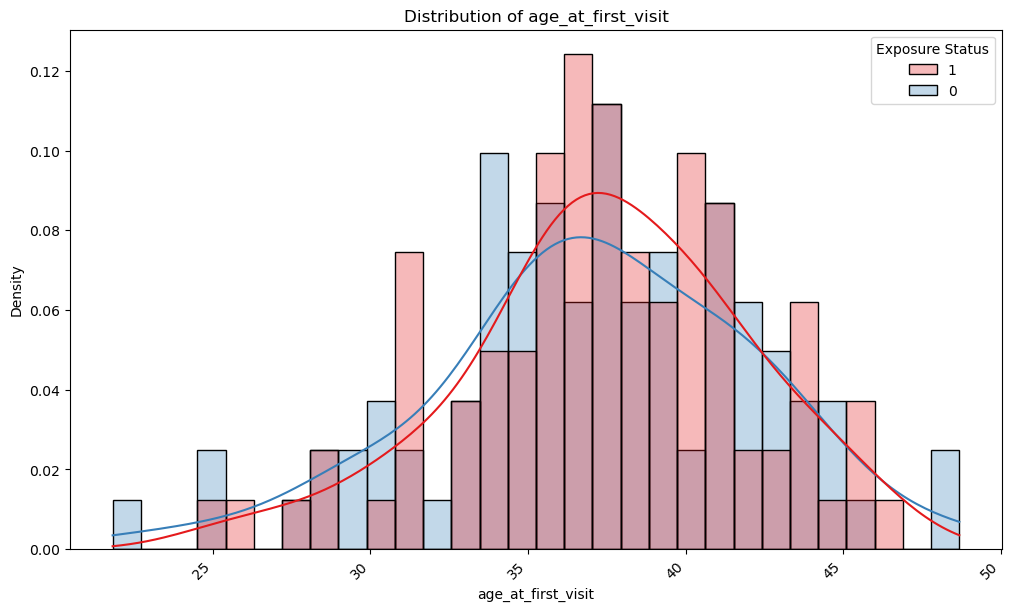

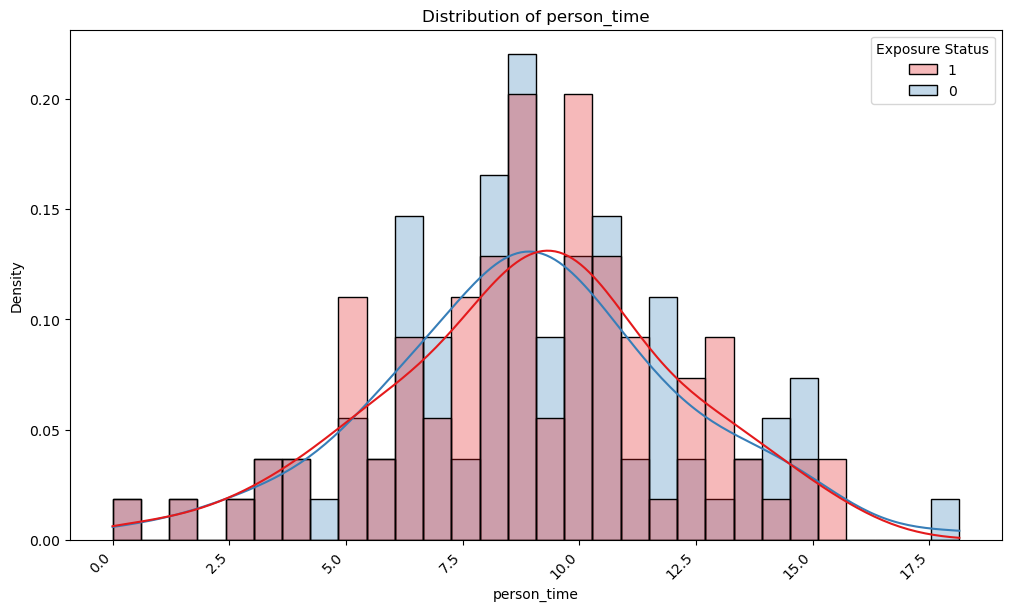

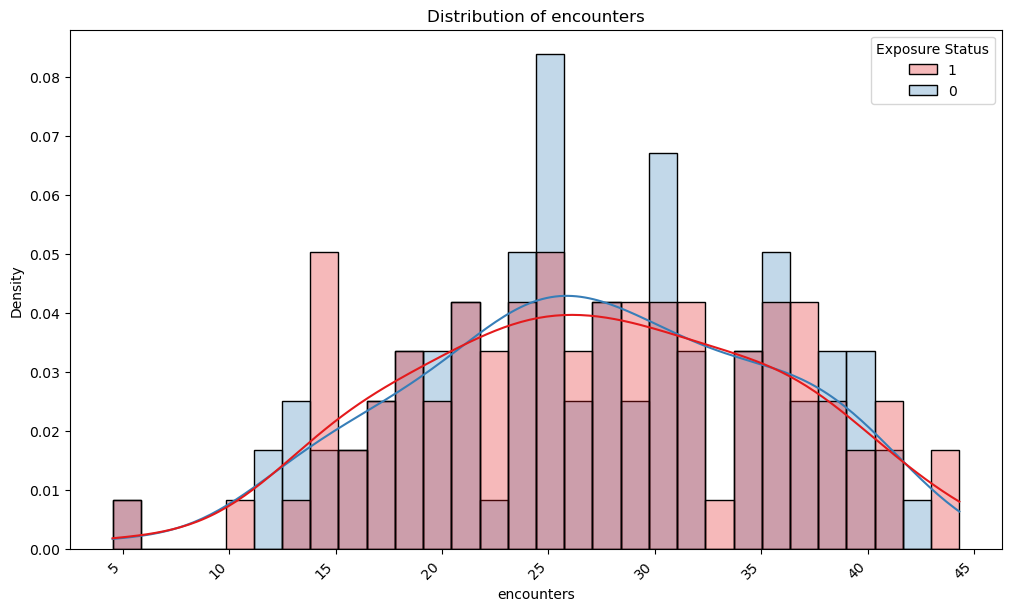

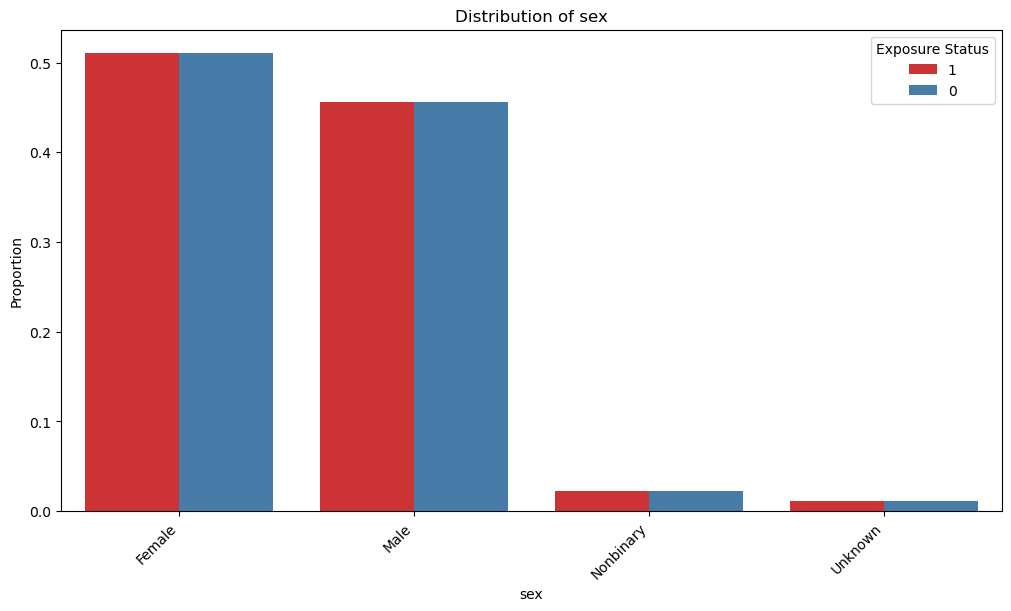

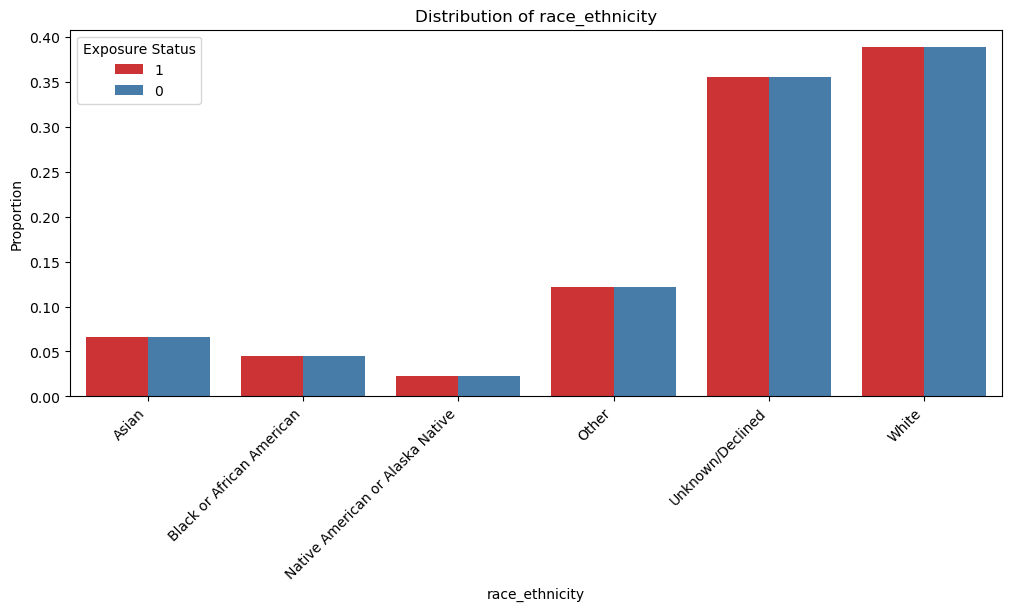

,patient_id,exposure_status,match_group,n_matches,match_distance,age_at_first_visit,person_time,encounters,sex,race_ethnicity
0,63,0,89.0,NaN,0.012954,36.876417,10.504789,40.756621,Female,White
1,346,0,69.0,NaN,0.012560,34.779476,10.925493,37.092856,Female,Unknown/Declined
2,398,0,88.0,NaN,0.015650,30.592820,8.740546,24.448006,Male,Asian
3,475,0,9.0,NaN,0.028048,34.051733,18.146031,24.606451,Male,Native American or Alaska Native
4,534,0,76.0,NaN,0.004964,42.964161,8.344965,26.205632,Female,Unknown/Declined


In [3]:
# Initialize the RDMatcher with Gower defaults (no one-hot encoding)
matcher = RDMatcher(
    pop_df=cohort,
    patient_id_col='patient_id',
    exposure_status='exposure_status',
    features_numeric=['age_at_first_visit', 'person_time', 'encounters'],
    features_categorical=['sex', 'race_ethnicity'],
    process_features=False,
    onehot=False,
    debug=False
)

# (Optional) Compute propensity logits — useful when using method='propensity'
# matcher.calculate_propensity_logits(method='simple')

# Run matching (Gower) — return matched data for immediate inspection
matched_df = matcher.rare_matching(
    threshold=0.1,
    n_neighbors=1,
    k_candidates=500,
    method='multi',
    distance_metric='gower',
    global_optimal=True,
    replacement=False,
    competitive_match=True,
    diagnostics=True,
    return_matched_data=True
)

matched_df.head()


In [4]:
# Show a brief diagnostics summary and plots
print('Summary table (top rows):')
matcher.summary_table

Summary table (top rows):


,Feature,Mean_Exposed,Std_Exposed,Mean_Control,Std_Control,SMD,SMD Result
0,age_at_first_visit,37.437,4.491,37.101,5.119,0.070,OK
1,person_time,8.980,3.134,8.983,3.226,0.001,OK
2,encounters,27.025,8.518,26.941,8.246,0.010,OK
3,sex_Unknown,1.111,NaN,1.111,NaN,0.000,OK
4,sex_Male,45.556,NaN,45.556,NaN,0.000,OK
5,sex_Nonbinary,2.222,NaN,2.222,NaN,0.000,OK
6,sex_Female,51.111,NaN,51.111,NaN,0.000,OK
7,race_ethnicity_Black or Africa,4.444,NaN,4.444,NaN,0.000,OK
8,race_ethnicity_Unknown/Decline,35.556,NaN,35.556,NaN,0.000,OK
9,race_ethnicity_Other,12.222,NaN,12.222,NaN,0.000,OK


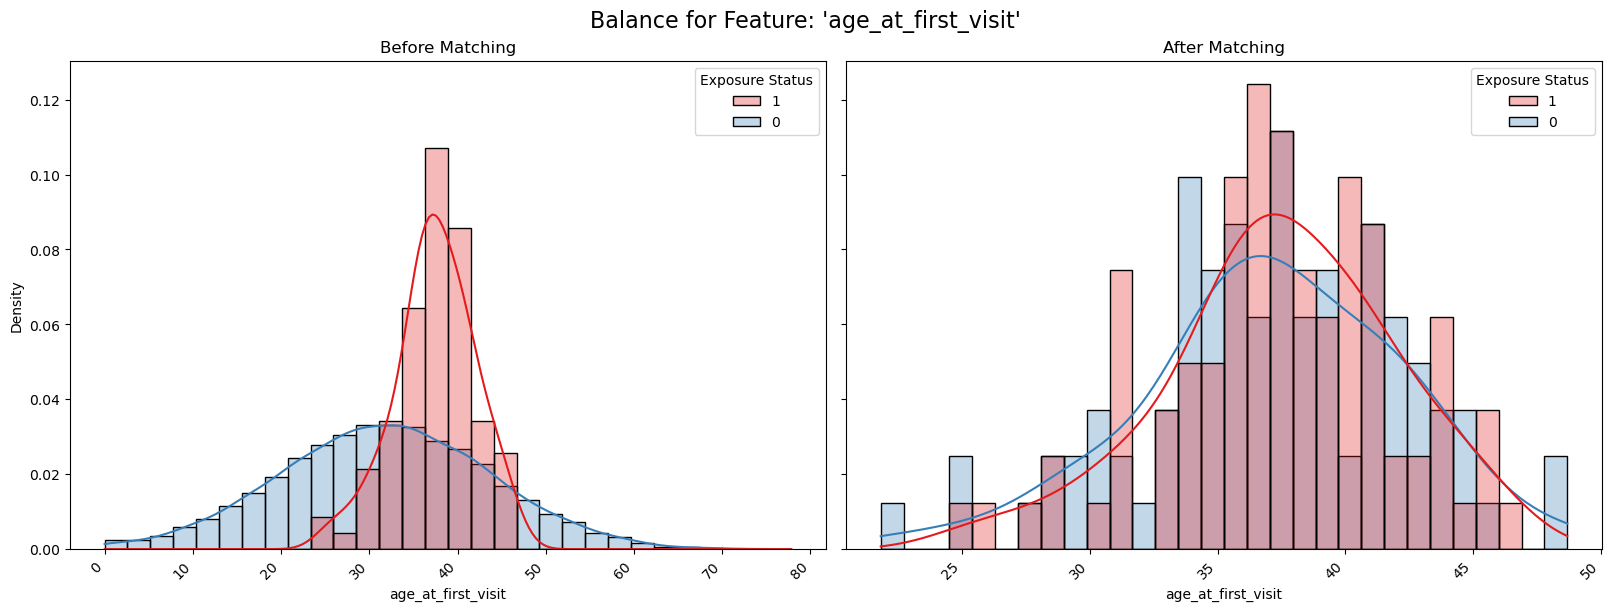

In [5]:

# Propensity coverage before/after matching
# matcher.plot_propensity_coverage(compare_matching=True, figsize=(10,4))


# Plot feature balance for a numeric feature
plot_feature_balance(cohort_before=matcher.pop, cohort_after=matcher.pop_matched, feature='age_at_first_visit', exposure_status_col='exposure_status', normalize=True)


In [6]:
# -----------------------------
# Propensity score examples
# -----------------------------

# 1) Fit a propensity model (formula-driven)
matcher.fit_propensity_model(formula='age_at_first_visit + sex + race_ethnicity', random_state=404)
matcher.logger.info('<system-reminder> propensity_logit added to data: {}'.format('propensity_logit' in matcher.pop.columns))
matched_propensity = matcher.rare_matching(threshold=0.1, n_neighbors=1, method='propensity', distance_metric='euclidean', return_matched_data=True)
matched_propensity.head()


,patient_id,exposure_status,propensity_logit,match_group,n_matches,match_distance,age_at_first_visit,person_time,encounters,sex,race_ethnicity,propensity_score
0,2,0,-4.587516,8,NaN,0.000000,NaN,NaN,NaN,None,None,0.010076
1,23,0,-4.587516,11,NaN,0.000000,NaN,NaN,NaN,None,None,0.010076
2,31,0,-4.587516,12,NaN,0.000000,NaN,NaN,NaN,None,None,0.010076
3,33,0,-4.587516,37,NaN,0.000000,NaN,NaN,NaN,None,None,0.010076
4,35,0,-4.818866,98,NaN,0.000059,32.514931,15.093912,11.096105,Male,Other,0.008011


## PSM + RDM Hybrid (Propensity Caliper + Gower Matching)

The recommended two-step approach (`ps_hybrid=True`):

1. **Fit a propensity model** to estimate each subject's probability of treatment.
2. **Apply a PS caliper** — for each treated subject, only controls within a propensity-based distance are eligible.
3. **Match on covariates using Gower distance** within the eligible set.

This prevents poor matches that are far apart on the propensity scale while still leveraging Gower's ability to handle mixed data types and missing values. Propensity is used *only* for filtering — it does **not** enter the Gower distance calculation, avoiding double-counting.

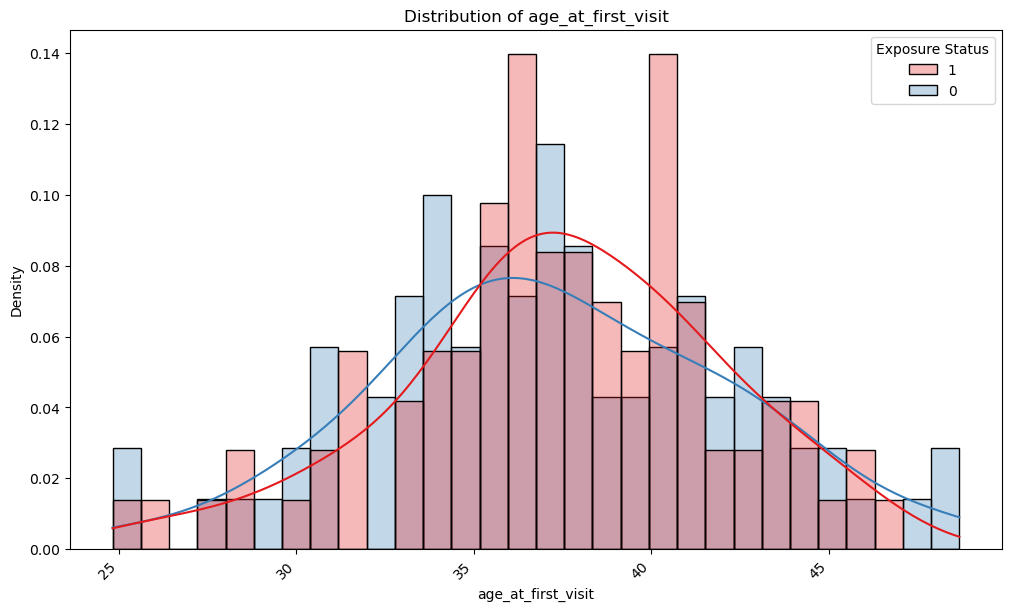

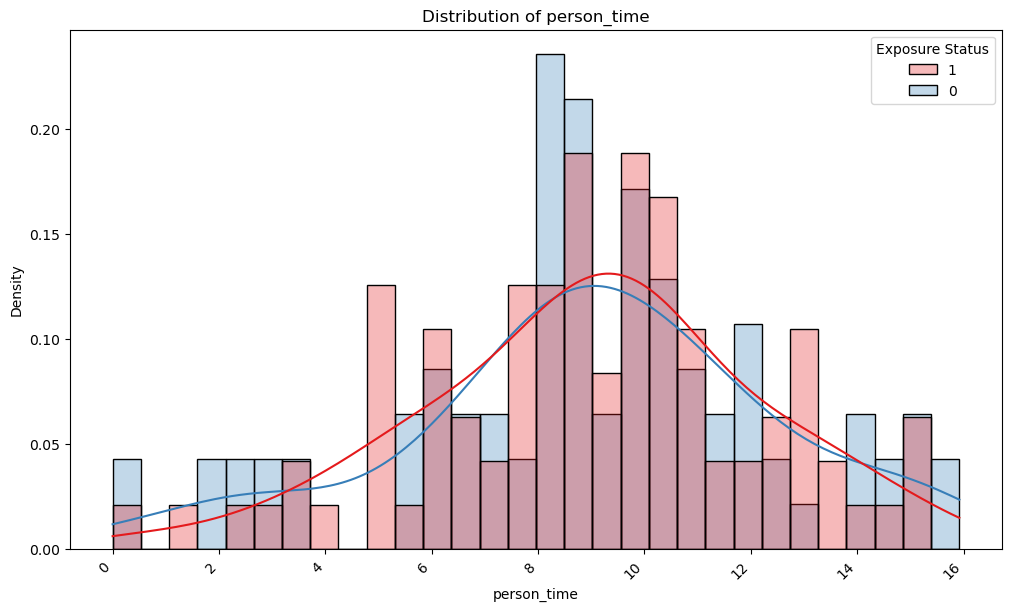

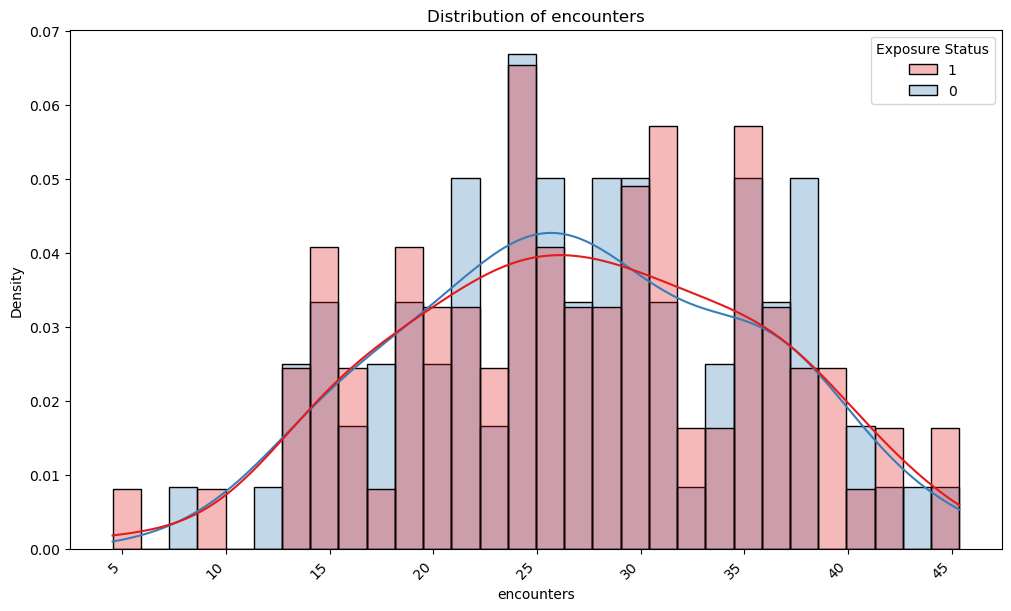

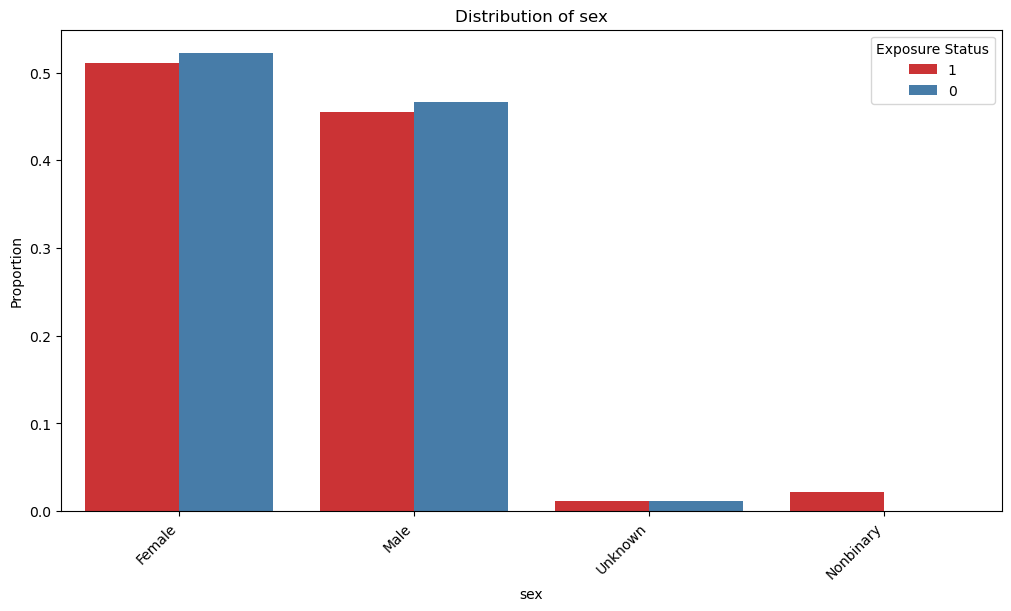

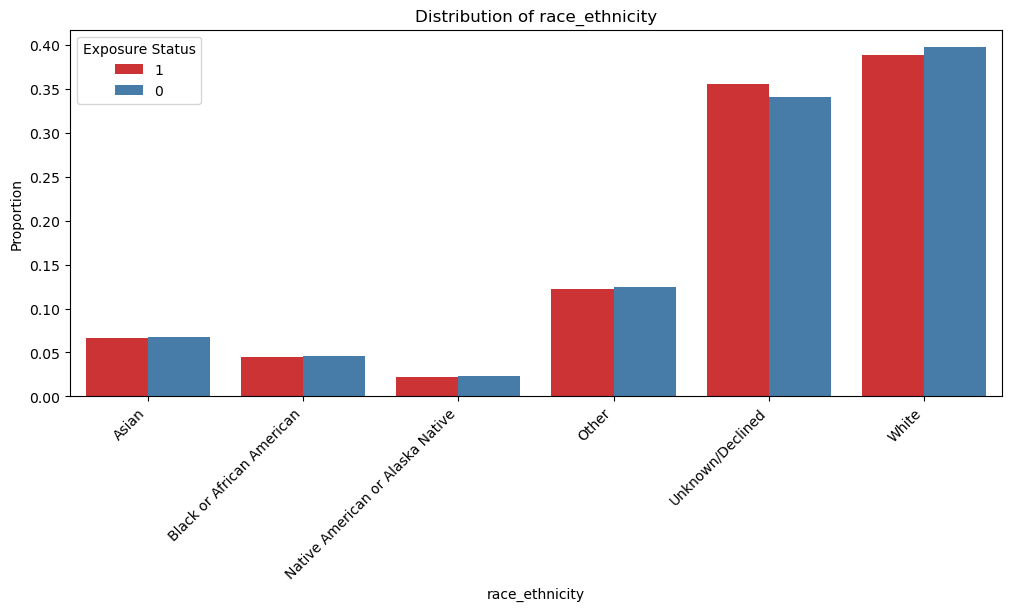

,patient_id,exposure_status,match_group,n_matches,match_distance,age_at_first_visit,person_time,encounters,sex,race_ethnicity,propensity_score,propensity_logit
0,37,0,61.0,NaN,0.021833,32.867704,8.538160,36.475607,Female,White,0.025283,-3.651995
1,63,0,87.0,NaN,0.012954,36.876417,10.504789,40.756621,Female,White,0.042391,-3.117507
2,346,0,68.0,NaN,0.012560,34.779476,10.925493,37.092856,Female,Unknown/Declined,0.031445,-3.427581
3,534,0,74.0,NaN,0.004964,42.964161,8.344965,26.205632,Female,Unknown/Declined,0.018674,-3.961765
4,539,0,58.0,NaN,0.008414,44.989125,2.544203,15.144575,Male,White,0.007325,-4.909119


In [7]:
# Re-initialize matcher (fresh start for hybrid demo)
matcher_hybrid = RDMatcher(
    pop_df=cohort,
    patient_id_col='patient_id',
    exposure_status='exposure_status',
    features_numeric=['age_at_first_visit', 'person_time', 'encounters'],
    features_categorical=['sex', 'race_ethnicity'],
    process_features=False,
    onehot=False,
    debug=False
)

# Step 1: Fit propensity model
matcher_hybrid.fit_propensity_model(
    formula='age_at_first_visit + person_time + encounters + sex + race_ethnicity',
    random_state=404
)

# Step 2: Match with PS caliper + Gower (ps_hybrid=True)
matched_hybrid = matcher_hybrid.rare_matching(
    threshold=0.1,
    n_neighbors=1,
    k_candidates=500,
    method='multi',
    distance_metric='gower',
    global_optimal=True,
    competitive_match=True,
    ps_hybrid=True,
    ps_caliper=0.2,
    ps_caliper_strict=True,
    diagnostics=True,
    return_matched_data=True
)

matched_hybrid.head()

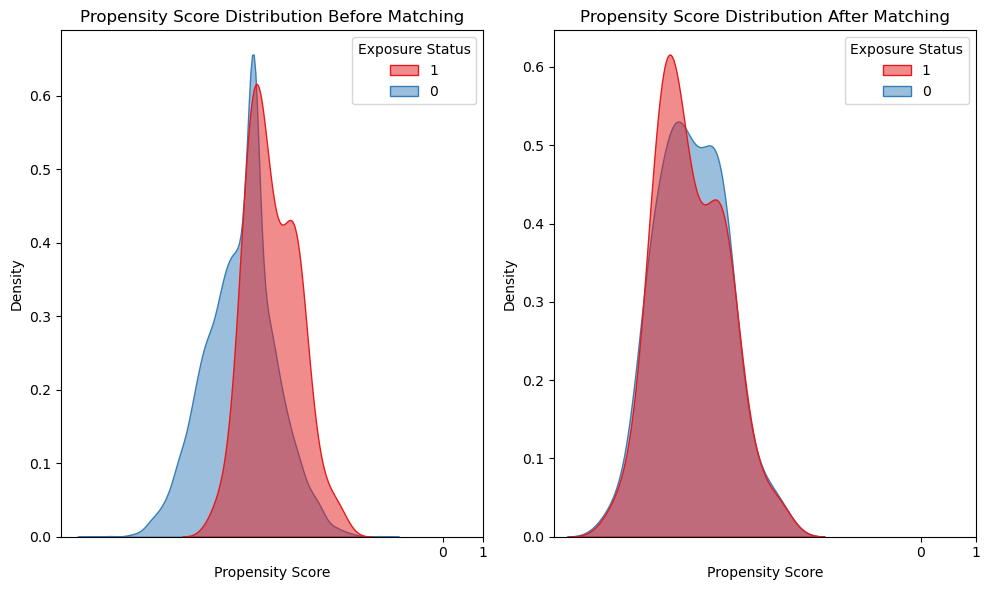

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: title={'center': 'Propensity Score Distribution Before Matching'}, xlabel='Propensity Score', ylabel='Density'>,
        <Axes: title={'center': 'Propensity Score Distribution After Matching'}, xlabel='Propensity Score', ylabel='Density'>],
       dtype=object))

In [8]:
# Propensity coverage: compare before and after hybrid matching
matcher_hybrid.plot_propensity_coverage(compare_matching=True)